[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/01_foundations/04_dictionaries_advanced.ipynb)

# 📓 Notebook 4 — Dictionaries: JSON, APIs, and LLM Messages

> **Module:** Data Structures · **Estimated time:** 35–45 min · **Difficulty:** Beginner

So far you've stored data as **values** (Notebook 1), made **decisions** over them (Notebook 2), and held **ordered sequences** of them (Notebook 3). But a great deal of real data isn't naturally ordered — it has **structure**:

> *Customer C-00482 is on the "Premium" plan, has MRR €1,250, signed up 18 months ago, and is flagged as a churn risk.*

A **dictionary** is Python's tool for exactly this: a collection of **key → value** pairs you look up by name.

**Our running example.** We'll follow that one customer record, `C-00482`, as it travels through a realistic AI workflow. It starts as a plain CRM record (§1–4), becomes a model **config** (§3), gets parsed back out of a JSON **API response** (§6), is folded into a list of **LLM chat messages** (§6), and finally joins a **batch of records** we count, group, and report on (§7–8). The same little dict, growing up. Along the way you'll see why dictionaries are the backbone of:

- **JSON** — every web API returns JSON, which becomes a Python dict.
- **LLM chat messages** — `{"role": "user", "content": "..."}` is a dict.
- **Configuration** — your model name, your prices, your thresholds.
- **Records** in pandas, where each row is essentially a dict.

If you only learn one new data structure in this course, make it this one.

> 🧭 **Mental model for the whole notebook.** A dictionary is a **labelled filing cabinet**: each drawer has a unique *label* (the **key**) and holds one *value*. You never search the cabinet drawer-by-drawer — you read the label and go *straight* to the right drawer. That "go straight there" is what makes lookups fast no matter how many drawers there are (we open up the machinery — *hashing* — in §2), and it's why labels have to be permanent and unchangeable.

## 🎯 Learning objectives

1. Create dictionaries and access values by key.
2. Add, update and delete entries safely.
3. Iterate over keys, values, and items.
4. Use **`.get()`** to handle missing keys without crashing.
5. Write **dict comprehensions** for fast transformations.
6. Nest dictionaries to model real-world structured data (JSON, API payloads).
7. Use dictionaries to **count and group** — the bedrock of analytics.
8. Decide when to use a list vs. a dictionary vs. a list of dictionaries.

## ✅ Prerequisites

Notebooks 1–3.

## 1. What is a dictionary? — the filing cabinet

Here's our customer record as Python sees it — the **labelled filing cabinet** from the intro. Each drawer has a *label* (the **key**) and contains some *value*:

```
       ┌──────── customer ────────┐
"customer_id"  →  "C-00482"
"plan"         →  "Premium"
"mrr_eur"      →  1_250
"months_active"→  18
"churn_risk"   →  True
```

- **Keys** must be unique and *immutable* — strings, numbers, or tuples. Not lists.
- **Values** can be anything — numbers, strings, lists, even other dictionaries.
- Dictionaries are **ordered** since Python 3.7 (keys keep their insertion order).

![A dict maps each unique key to exactly one value — d["plan"] follows the arrow](attachment:dict_mapping.png)

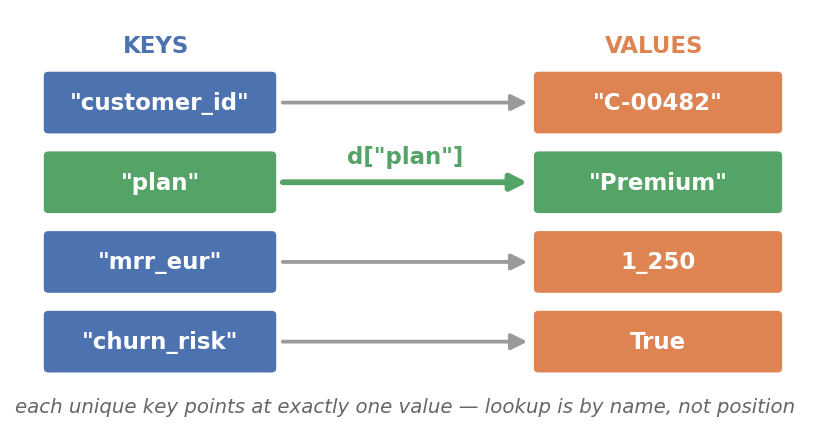

In [1]:
# Create a dictionary that looks suspiciously like a row of a CRM
customer = {
    "customer_id":   "C-00482",
    "plan":          "Premium",
    "mrr_eur":       1_250,
    "months_active": 18,
    "churn_risk":    True,
}

print(customer)
print(f"\nNumber of fields: {len(customer)}")


{'customer_id': 'C-00482', 'plan': 'Premium', 'mrr_eur': 1250, 'months_active': 18, 'churn_risk': True}

Number of fields: 5


> 💡 **JSON-shaped.** Print a Python dict and what you see is *almost* JSON. The two are so similar that `json.dumps(d)` and `json.loads(s)` convert between them with no friction.

## 2. Accessing values — reading a drawer

A filing cabinet is only useful if you can pull out the drawer you want. With a dict you name the label — but there's a fork in the road that trips up everyone, and it matters enormously once you're parsing data you didn't create: **what happens when the drawer isn't there?**

Two ways to read, with very different manners: square brackets (strict — *crashes* on a missing key) and `.get()` (gentle — hands back a default). Knowing when to use which is half of robust API parsing.

In [2]:
# Strict access with square brackets
print(f"Plan : {customer['plan']!r}")
print(f"MRR  : €{customer['mrr_eur']}")

# Missing key raises KeyError
try:
    print(customer["industry"])
except KeyError as e:
    print(f"\nKeyError on missing key: {e}")


Plan : 'Premium'
MRR  : €1250

KeyError on missing key: 'industry'


In [3]:
# Defensive access with .get()  — your best friend when parsing API responses
print(f"Industry  : {customer.get('industry')}")              # → None
print(f"Industry  : {customer.get('industry', 'unknown')!r}") # → 'unknown'

# A common combo: get-or-default in one line
country = customer.get("country", "DE")
print(f"Country   : {country}")


Industry  : None
Industry  : 'unknown'
Country   : DE


> 🚫 **Misconception — "`d.get(key, default)` adds the key to the dict."**
> `.get` only **reads**. If the key is missing it just *returns* the default — it does **not** insert anything, so the dict is unchanged. If you actually want "return it, and also store it if absent", that's a different method: `d.setdefault(key, default)`.


> ⚠️ **API parsing rule of thumb.** When you read JSON from someone else's API, **assume every field might be missing**. Use `.get(key, default)` everywhere — the alternative is your script crashing in production on a field you didn't know existed.

### 🔬 What actually happens when you write `d[key]`?

You've now seen `d["plan"]` (fetch) and `"plan" in d` (membership test). Both feel instant — even if the dict had a *million* keys, they'd still be fast. That is not an accident. Understanding *why* explains a rule you'll hit constantly: **why some things can be dict keys and others raise `TypeError`.**

The secret is **hashing**. Python never scans the dict key-by-key. Instead it does three steps:

**Step 1 — hash the key into a number.** Every key is passed through the built-in `hash()` function, which turns it into a (possibly huge) integer:

```python
hash("plan")   →  <some big integer>       # e.g. 4470321191328281210
```

(The exact value differs from run to run for strings — see the note below — so treat the numbers here as *illustrative*.)

**Step 2 — turn that number into a bucket index.** A dict stores its data in a backing array of *buckets*. Python reduces the hash to a slot number (conceptually `hash(key) % number_of_buckets`):

```python
<that big integer>  %  8   →   3           # → bucket 3
```

**Step 3 — go straight to that bucket.** Python jumps directly to bucket 3 and finds the value sitting there. No scanning. That's why it's **~O(1)** — *roughly constant time on average*, almost independent of how many keys exist. (When two keys land in the same bucket — a *collision* — Python probes a few nearby slots, so the worst case is technically O(n); in practice that's vanishingly rare and lookups stay fast.)

```text
   d = {"plan": "Premium", "mrr_eur": 1250, "churn_risk": True}

        "plan"            "mrr_eur"          "churn_risk"
          │                   │                   │
       hash(...)           hash(...)           hash(...)
          │                   │                   │
        % 8 = 3             % 8 = 6             % 8 = 1
          │                   │                   │
          ▼                   ▼                   ▼
   ┌────┬────┬────┬────────────┬────┬────┬──────────┬────┐
   │ 0  │ 1  │ 2  │     3      │ 4  │ 5  │    6     │ 7  │
   │    │chu.│    │"plan":Prem │    │    │mrr:1250  │    │   ← buckets
   └────┴────┴────┴────────────┴────┴────┴──────────┴────┘
```

To **read** `d["plan"]`: hash `"plan"` again → bucket 3 → return `"Premium"`. To **test** `"plan" in d`: same hash, same jump, check whether the bucket is occupied. Same trick powers a **`set`**, which is just a dict that stores keys with no values.


### List scan vs dict lookup — why the difference matters

A list has **no** key→bucket trick. To answer `"plan" in my_list`, Python must walk the list from the front, comparing each element until it finds a match (or reaches the end). That's **O(n)** — the cost grows with the size of the list.

| | `x in my_list` | `key in my_dict` / `x in my_set` |
|---|---|---|
| How it searches | Walks element by element | Hashes the key, jumps to one bucket |
| Cost | **O(n)** — grows with size | **~O(1)** — flat, independent of size |
| 10 items | ~10 comparisons (worst case) | ~1 lookup |
| 1,000,000 items | ~1,000,000 comparisons | still ~1 lookup |
| Needs | nothing special | the key must be **hashable** |

> 🎯 **Intuition.** A list is like flipping through a book page by page to find a word. A dict is like the book's *index* at the back: you compute roughly where the word is and jump straight there. For a *membership test over a big collection*, reach for a `set` or `dict`, not a `list`.


In [4]:
# DEMO 1 — peek at the hash() that powers every lookup
for key in ["plan", "mrr_eur", "churn_risk", 42, (1, 2)]:
    print(f"hash({key!r:<12}) = {hash(key)}")

# The SAME key always hashes to the SAME number within a run — that's what
# lets Python find it again later. (Strings use a per-process random seed,
# so the exact numbers differ between runs — but stay constant *within* a run.)
print("\nStable within a run:", hash("plan") == hash("plan"))   # always True


# DEMO 2 — ~O(1) dict/set membership vs O(n) list scan, timed on a big container
import time

N      = 1_000_000
big_list = list(range(N))      # a list   — membership is O(n)
big_set  = set(range(N))       # a set    — membership is ~O(1)
needle   = N - 1               # worst case for the list: the very last element

t0 = time.perf_counter(); (needle in big_list); t_list = time.perf_counter() - t0
t1 = time.perf_counter(); (needle in big_set);  t_set  = time.perf_counter() - t1

print(f"\n'{needle} in list' : {t_list*1e6:8.1f} µs   (scans up to {N:,} items)")
print(f"'{needle} in set'  : {t_set*1e6:8.1f} µs   (one hash + one jump)")
print(f"set is ~{t_list / max(t_set, 1e-9):.0f}x faster here")


hash('plan'      ) = -1171679200376577657
hash('mrr_eur'   ) = 4490617676520589128
hash('churn_risk') = -2824984128620039872
hash(42          ) = 42
hash((1, 2)      ) = -3550055125485641917

Stable within a run: True

'999999 in list' :   4046.5 µs   (scans up to 1,000,000 items)
'999999 in set'  :     10.7 µs   (one hash + one jump)
set is ~379x faster here


### Behind the scenes — why keys must be *hashable* (immutable)

Here's the catch that the bucket trick forces on us. Python finds a key by **re-hashing it** and going to the bucket that hash points to. For that to work, a key's hash must **never change** after it's stored. If it could change, the key would hash to a *different* bucket on lookup — and Python would look in the wrong place and "lose" the value.

So Python only allows **hashable** keys — and *hashable* effectively means **immutable**:

| Type | Hashable? | Can be a dict key / set member? |
|---|---|---|
| `str` (`"plan"`) | ✅ yes | ✅ yes |
| `int`, `float`, `bool` | ✅ yes | ✅ yes |
| `tuple` of hashables (`(1, 2)`) | ✅ yes | ✅ yes |
| `list` (`[1, 2]`) | ❌ no | ❌ **`TypeError`** |
| `dict` | ❌ no | ❌ **`TypeError`** |
| `set` | ❌ no | ❌ **`TypeError`** |

Why are `list`, `dict`, and `set` banned? Because they're **mutable** — you can change their contents after creation. If `[1, 2]` were a key and you later did `key.append(3)`, its hash would change and the value would become unreachable. Python forbids it up front rather than letting you create a silent, un-findable entry.

> 🧠 **Mental model.** A dict key is a *permanent address*. You can only use something as an address if it promises never to change — that promise is exactly what "immutable / hashable" means. The fix when you need a multi-part key is to use a **tuple** instead of a list: `d[(row, col)] = ...` works; `d[[row, col]] = ...` does not.


In [5]:
# PROOF — a list CANNOT be a key (caught so the cell still runs cleanly)
try:
    bad = {[1, 2]: "nope"}          # list is mutable → unhashable
except TypeError as e:
    print("list as key  →  TypeError:", e)

# The standard fix: use an IMMUTABLE tuple instead of a mutable list
grid = {}
grid[(0, 0)] = "top-left"           # tuple key — totally fine
grid[(1, 2)] = "row 1, col 2"
print("\ntuple keys work fine:", grid)
print("lookup grid[(1, 2)] →", grid[(1, 2)])

# Same rule for sets — they store hashable members only
try:
    s = {[1, 2], [3, 4]}            # set of lists → also unhashable
except TypeError as e:
    print("\nlist in a set →  TypeError:", e)

print("set of tuples is fine →", {(1, 2), (3, 4)})


list as key  →  TypeError: unhashable type: 'list'

tuple keys work fine: {(0, 0): 'top-left', (1, 2): 'row 1, col 2'}
lookup grid[(1, 2)] → row 1, col 2

list in a set →  TypeError: unhashable type: 'list'
set of tuples is fine → {(1, 2), (3, 4)}


### Order is remembered, but lookup is *not* by position

One more subtlety that surprises people. Since Python 3.7, a dict **preserves insertion order** — iterate it and you get keys back in the order you added them. So it's tempting to think a dict is "ordered like a list."

It isn't, in the way that matters for *lookup*. Insertion order is just bookkeeping Python keeps alongside the buckets so iteration is predictable. **Finding** a key still goes through `hash(key)` → bucket — never through a position. There is no `d[0]` meaning "the first item"; `d[0]` means "the value stored under the integer key `0`", and raises `KeyError` if there isn't one.

```text
  Two independent facts about a dict:

  ① ITERATION order   →  insertion order   ("plan" added before "mrr" ⇒ comes first)
  ② LOOKUP mechanism  →  hash(key) → bucket (position is irrelevant)
```


In [6]:
# Insertion order is preserved on iteration...
d = {}
d["plan"] = "Premium"
d["mrr_eur"] = 1250
d["churn_risk"] = True
print("Iterates in insertion order:", list(d))   # ['plan', 'mrr_eur', 'churn_risk']

# ...but lookup is by KEY, never by position — there is no d[0] "first item":
try:
    print(d[0])                                   # asks for the key 0, which doesn't exist
except KeyError as e:
    print("d[0] → KeyError:", e, "(0 is not a key here, not 'position 0')")


Iterates in insertion order: ['plan', 'mrr_eur', 'churn_risk']
d[0] → KeyError: 0 (0 is not a key here, not 'position 0')


> ⚠️ **Pitfall — don't rely on `dict` for positional access.** If you genuinely want "the 3rd thing", use a **list**. Use a dict when you look things up **by name**. The insertion-order guarantee is great for *reproducible iteration and clean JSON*, not for indexing by number.

> 🧠 **The one-sentence takeaway.** A dict (and a set) trades a little memory for a **hash table** that turns "is this key here, and what's its value?" into a single jump instead of a scan — which is why lookups stay fast (≈O(1) on average) regardless of size, and why keys must be immutable so their address never moves.


---

### ✋ Quick exercise (~2 min) — Defensive read with `.get()`

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

You're parsing one row of a CRM export. Read the customer's `country` field, but it might be missing — default to `"DE"` instead of crashing. Then read `plan`, which is present.

```python
record = {"customer_id": "C-00993", "plan": "Standard", "mrr_eur": 420}
```

In [ ]:
# ✍️ Your turn 👇
record = {"customer_id": "C-00993", "plan": "Standard", "mrr_eur": 420}

# TODO: read 'country' with default "DE", and read 'plan'
country = ...
plan = ...
print(country, plan)

<details>
<summary>✅ <b>Solution</b></summary>

```python
country = record.get("country", "DE")    # → "DE"  (field is missing)
plan    = record.get("plan", "unknown")  # → "Standard"
print(country, plan)
```

`d.get(key, default)` returns the default for a missing key instead of raising `KeyError` — the safe way to read fields from data you didn't create.
</details>

## 3. Adding, updating, removing — the record grows up

Our customer record didn't arrive complete, and neither will most of yours. A config dict starts with a couple of settings and gains more; an API payload gets a field patched in; a stale flag gets removed. Because a dict is **mutable**, you can do all of that in place after creation. Here the running example shifts costume — same dict mechanics, now holding a *model config* instead of a customer.

In [7]:
# Start with a partial record
config = {"model": "gpt-4o-mini", "temperature": 0.0}
print("Before :", config)

# Add a new key
config["max_tokens"] = 1024

# Update an existing key
config["temperature"] = 0.3

# Update many at once with .update()
config.update({
    "top_p":         1.0,
    "system_prompt": "You are a helpful assistant.",
})

# Remove a key
del config["top_p"]

# Or pop — remove AND return (great with a default to avoid KeyError)
removed = config.pop("system_prompt", None)
print(f"\nRemoved system_prompt: {removed!r}")

print("\nAfter  :", config)


Before : {'model': 'gpt-4o-mini', 'temperature': 0.0}

Removed system_prompt: 'You are a helpful assistant.'

After  : {'model': 'gpt-4o-mini', 'temperature': 0.3, 'max_tokens': 1024}


## 4. Iterating — walking every drawer

Reading one drawer by label is the common case. But often you want to *walk the whole cabinet* — print every field of the customer record, or tally every setting. A dict gives you three ways to loop, depending on whether you want the labels, the contents, or both:

In [8]:
customer = {
    "customer_id":   "C-00482",
    "plan":          "Premium",
    "mrr_eur":       1_250,
    "months_active": 18,
    "churn_risk":    True,
}

# 1) Keys (the default when you iterate a dict)
print("Keys:")
for k in customer:
    print(f"  {k}")

# 2) Values
print("\nValues:")
for v in customer.values():
    print(f"  {v!r}")

# 3) Items — the most useful: (key, value) pairs
print("\nItems:")
for key, value in customer.items():
    print(f"  {key:<14} → {value!r}")


Keys:
  customer_id
  plan
  mrr_eur
  months_active
  churn_risk

Values:
  'C-00482'
  'Premium'
  1250
  18
  True

Items:
  customer_id    → 'C-00482'
  plan           → 'Premium'
  mrr_eur        → 1250
  months_active  → 18
  churn_risk     → True


> 💡 **Iterate dict items, not keys.** When you find yourself writing `for k in d: ... d[k]`, switch to `for k, v in d.items():`. It's faster *and* more readable.

## 5. Dict comprehensions — build a cabinet in one line

Remember the list comprehension from NB 3 — the one-line way to build a list from a loop? Dictionaries get the exact same gift. When you find yourself starting an empty dict and filling it in a loop (a price lookup, a discounted copy, a filtered subset), a **dict comprehension** collapses that to one expressive line:

```
{ key_expr: value_expr for item in iterable if condition }
```

Three patterns that come up daily:

In [9]:
# Pattern 1: build a price lookup from two parallel lists
skus    = ["SKU-001", "SKU-002", "SKU-003", "SKU-004"]
prices  = [12.50,     7.99,      29.00,     4.20]

price_lookup = {sku: price for sku, price in zip(skus, prices)}
print(price_lookup)

# Pattern 2: transform values — apply a 10% discount
discounted = {sku: round(p * 0.9, 2) for sku, p in price_lookup.items()}
print("\nDiscounted:", discounted)

# Pattern 3: filter — keep only items above a threshold
expensive = {sku: p for sku, p in price_lookup.items() if p > 10}
print("\nExpensive only:", expensive)


{'SKU-001': 12.5, 'SKU-002': 7.99, 'SKU-003': 29.0, 'SKU-004': 4.2}

Discounted: {'SKU-001': 11.25, 'SKU-002': 7.19, 'SKU-003': 26.1, 'SKU-004': 3.78}

Expensive only: {'SKU-001': 12.5, 'SKU-003': 29.0}


---

### ✋ Quick exercise (~2 min) — Cost lookup in one line

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

You have the token count used by each model. Using a **single dict comprehension**, build a new dict mapping each model to its cost in euros, charged at €0.002 per 1,000 tokens.

```python
tokens = {"gpt-4o-mini": 12000, "claude-haiku": 3500, "gemini-flash": 8000}
```

In [ ]:
# ✍️ Your turn 👇
tokens = {"gpt-4o-mini": 12000, "claude-haiku": 3500, "gemini-flash": 8000}

# TODO: build cost = {model: euros} at €0.002 per 1000 tokens, in one comprehension
cost = ...
print(cost)

<details>
<summary>✅ <b>Solution</b></summary>

```python
cost = {model: round(t / 1000 * 0.002, 4) for model, t in tokens.items()}
print(cost)
# → {'gpt-4o-mini': 0.024, 'claude-haiku': 0.007, 'gemini-flash': 0.016}
```

A dict comprehension `{k: expr for k, v in d.items()}` transforms every value of a dict in one readable line — no empty dict and `for`-loop needed.
</details>

## 6. Nested dictionaries — our record, as JSON

So far each value has been a simple scalar. The real power — and the reason dictionaries run the modern internet — shows up when a value is *itself* a dict, or a list of dicts. That's not an edge case: it's the **exact** shape every API response arrives in. Our customer workflow now hits the network, and the reply comes back as a nested dict we have to drill into.

In [10]:
# A typical API response — exactly the shape JSON gives you
api_response = {
    "request_id": "req_9472193",
    "model":      "gpt-4o-mini",
    "usage": {
        "input_tokens":  482,
        "output_tokens": 121,
        "total_tokens":  603,
    },
    "choices": [
        {
            "index":   0,
            "message": {"role": "assistant", "content": "Refunds take 5 business days."},
            "finish_reason": "stop",
        }
    ],
}

# Drill down step by step
print("Model       :", api_response["model"])
print("Total tokens:", api_response["usage"]["total_tokens"])
print("Reply text  :", api_response["choices"][0]["message"]["content"])


Model       : gpt-4o-mini
Total tokens: 603
Reply text  : Refunds take 5 business days.


> 🎯 **Reading nested data.** Each `[ ... ]` peels one layer. If you're ever lost, `print(type(thing))` tells you *whether you're holding a dict or a list*. Lists are indexed by `[0]`, `[1]`, …; dicts by `["key"]`.

### A defensive parser

In production you don't trust the API to always return the same shape. The pattern below — *get-with-default at every layer* — is what you'll write hundreds of times.

In [11]:
def extract_reply(resp):
    """Pull the assistant message out of a chat-completion-style response,
    falling back gracefully when fields are missing."""
    choices = resp.get("choices") or []
    if not choices:
        return None
    first = choices[0]
    message = first.get("message") or {}
    return message.get("content")


print(extract_reply(api_response))                       # → real text
print(extract_reply({}))                                 # → None, no crash
print(extract_reply({"choices": []}))                    # → None, no crash
print(extract_reply({"choices": [{"foo": "bar"}]}))      # → None, no crash


Refunds take 5 business days.
None
None
None


### LLM chat messages — a list of dicts

The chat APIs of every major LLM provider — OpenAI, Anthropic, Google, open-source models — use the same shape: a list of messages, where each message is a dict with `role` and `content`.

In [12]:
messages = [
    {"role": "system",    "content": "You classify customer messages by topic."},
    {"role": "user",      "content": "I was charged twice this month."},
    {"role": "assistant", "content": "billing"},
    {"role": "user",      "content": "My password reset link is broken."},
]

# Tally the roles
from collections import Counter
roles = Counter(m["role"] for m in messages)
print("Role counts:", dict(roles))

# Just the user messages, please
user_msgs = [m["content"] for m in messages if m["role"] == "user"]
print("\nUser messages:")
for u in user_msgs:
    print(f"  - {u}")


Role counts: {'system': 1, 'user': 2, 'assistant': 1}

User messages:
  - I was charged twice this month.
  - My password reset link is broken.


## 7. Counting and grouping — the dictionary's killer app

One record is easy. The questions that *earn their keep* are about the whole **batch**: *how many tickets of each priority? how much MRR per plan? what's the sentiment per channel?* Every one of those is a count-or-group, and the dictionary — label → running tally — is the perfect tool for it. (Pandas will do this in one line later; doing it by hand once makes the mechanics obvious — and shows you exactly what `groupby` is doing under the hood.)

In [13]:
# A small batch of (channel, sentiment) pairs from yesterday's feedback
events = [
    ("Email",   "negative"),
    ("Chat",    "positive"),
    ("Email",   "positive"),
    ("Phone",   "negative"),
    ("Chat",    "positive"),
    ("Email",   "neutral"),
    ("Chat",    "negative"),
    ("Web",     "positive"),
    ("Phone",   "negative"),
    ("Chat",    "positive"),
]

# Pattern 1: count occurrences of a single field
sentiment_counts = {}
for _, sentiment in events:
    sentiment_counts[sentiment] = sentiment_counts.get(sentiment, 0) + 1

print("Sentiment counts:", sentiment_counts)


Sentiment counts: {'negative': 4, 'positive': 5, 'neutral': 1}


In [14]:
# Pattern 2: group items by a key — sentiment per channel
grouped = {}
for channel, sentiment in events:
    grouped.setdefault(channel, []).append(sentiment)

for ch, items in grouped.items():
    print(f"  {ch:<6}: {items}")


  Email : ['negative', 'positive', 'neutral']
  Chat  : ['positive', 'positive', 'negative', 'positive']
  Phone : ['negative', 'negative']
  Web   : ['positive']


> 💡 **`setdefault(key, [])`** is the classic trick: "if this key doesn't exist yet, start an empty list, then return whatever is there (new or existing) so I can append to it." It saves you a two-line `if key in d:` check every time.

In [15]:
# Pattern 3: the same with collections.Counter — when you really just need counts
from collections import Counter, defaultdict

by_channel = Counter(ch for ch, _ in events)
print("By channel:", dict(by_channel))

# defaultdict — like setdefault but cleaner when you'll append many times
grouped2 = defaultdict(list)
for channel, sentiment in events:
    grouped2[channel].append(sentiment)

print("\nGrouped (defaultdict):")
for ch, items in grouped2.items():
    print(f"  {ch:<6}: {items}")


By channel: {'Email': 3, 'Chat': 4, 'Phone': 2, 'Web': 1}

Grouped (defaultdict):
  Email : ['negative', 'positive', 'neutral']
  Chat  : ['positive', 'positive', 'negative', 'positive']
  Phone : ['negative', 'negative']
  Web   : ['positive']


### The Counter, as a frequency bar

Counting-by-key is the dictionary's killer app. The `by_channel` Counter we just built is exactly the data a bar chart wants.

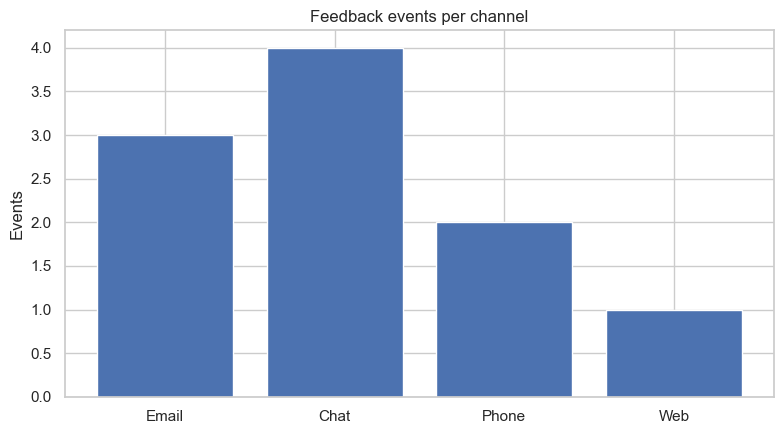

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
channels = list(by_channel.keys())
counts   = [by_channel[c] for c in channels]
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(channels, counts, color='#4C72B0')
ax.set_ylabel("Events")
ax.set_title("Feedback events per channel")
plt.tight_layout()
plt.show()


**How to read it:** each bar's height is the count the Counter tallied for that channel — the tallest bar is your busiest channel.

---

### ✋ Quick exercise (~2 min) — Tally by priority

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

From yesterday's support queue, count how many tickets fall into each priority using the **dict-counter pattern** `d[k] = d.get(k, 0) + 1` (no `Counter` import).

```python
priorities = ["high", "low", "high", "medium", "high", "low"]
```

In [ ]:
# ✍️ Your turn 👇
priorities = ["high", "low", "high", "medium", "high", "low"]

counts = {}
# TODO: tally each priority into counts
print(counts)

<details>
<summary>✅ <b>Solution</b></summary>

```python
counts = {}
for p in priorities:
    counts[p] = counts.get(p, 0) + 1
print(counts)   # {'high': 3, 'low': 2, 'medium': 1}
```

`counts.get(p, 0) + 1` starts a never-seen key at 0 and increments it — the universal counting idiom that `Counter` automates for you.
</details>

## 8. List of dicts — the "small table" pattern

A *list of dicts* is the natural shape for a small table where each item has named fields. It's what `pd.DataFrame(records)` consumes, and it's what JSON arrays-of-objects deserialise to.

In [17]:
customers = [
    {"id": "C-001", "plan": "Premium",    "mrr": 1_250, "months": 18, "risk": False},
    {"id": "C-002", "plan": "Standard",   "mrr":   420, "months":  7, "risk": True},
    {"id": "C-003", "plan": "Enterprise", "mrr": 5_800, "months": 32, "risk": False},
    {"id": "C-004", "plan": "Free",       "mrr":   110, "months":  3, "risk": True},
    {"id": "C-005", "plan": "Premium",    "mrr": 2_900, "months": 21, "risk": False},
]

# Total MRR
total_mrr = sum(c["mrr"] for c in customers)
print(f"Total MRR        : €{total_mrr:,}")

# At-risk MRR
risk_mrr = sum(c["mrr"] for c in customers if c["risk"])
print(f"At-risk MRR      : €{risk_mrr:,}  ({risk_mrr/total_mrr:.1%} of total)")

# Top by MRR
top = max(customers, key=lambda c: c["mrr"])
print(f"Top customer     : {top['id']} ({top['plan']}, €{top['mrr']:,})")


Total MRR        : €10,480
At-risk MRR      : €530  (5.1% of total)
Top customer     : C-003 (Enterprise, €5,800)


## 9. JSON round-trip — the API workflow

The `json` module converts between Python dicts and JSON strings. This is *the* skill for working with APIs.

In [18]:
import json

# Python dict → JSON string  (what you'd send to a server)
payload = {
    "model":       "gpt-4o-mini",
    "temperature": 0.0,
    "messages":    [
        {"role": "system", "content": "You are helpful."},
        {"role": "user",   "content": "Hello!"},
    ],
}

payload_json = json.dumps(payload, indent=2)
print("=== Outgoing JSON ===")
print(payload_json)

# JSON string → Python dict  (what you'd get back)
incoming = '{"id": "msg_001", "usage": {"input": 12, "output": 5}}'
parsed = json.loads(incoming)
print("\n=== Parsed dict ===")
print(parsed)
print("Type :", type(parsed).__name__)
print("Total:", parsed["usage"]["input"] + parsed["usage"]["output"])


=== Outgoing JSON ===
{
  "model": "gpt-4o-mini",
  "temperature": 0.0,
  "messages": [
    {
      "role": "system",
      "content": "You are helpful."
    },
    {
      "role": "user",
      "content": "Hello!"
    }
  ]
}

=== Parsed dict ===
{'id': 'msg_001', 'usage': {'input': 12, 'output': 5}}
Type : dict
Total: 17


> ⚠️ **Always wrap `json.loads` in `try / except json.JSONDecodeError`** when the JSON comes from the outside world. One bad response from one bad request shouldn't kill an entire batch job.

---

### ✋ Quick exercise (~2 min) — Parse an API response

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

An API handed you this raw JSON **string**. Parse it into a Python dict, then compute the total token usage (`input` + `output`).

```python
raw = '{"id": "msg_77", "usage": {"input": 30, "output": 12}}'
```

In [ ]:
# ✍️ Your turn 👇
import json
raw = '{"id": "msg_77", "usage": {"input": 30, "output": 12}}'

# TODO: parse raw into a dict, then total = input + output
data = ...
total = ...
print(total)

<details>
<summary>✅ <b>Solution</b></summary>

```python
import json
data = json.loads(raw)
total = data["usage"]["input"] + data["usage"]["output"]
print(total)   # 42
```

`json.loads` turns a JSON string into a Python dict — after that it's just ordinary nested-dict access with `["key"]`.
</details>

## 10. List vs dict vs list-of-dicts — choosing the right shape

| Question                                            | Best shape         |
|-----------------------------------------------------|--------------------|
| "Do these values have an order, like a queue?"      | **list**           |
| "Do I look up by a *name*, not a position?"         | **dict**           |
| "Do I have many records, each with named fields?"   | **list of dicts**  |
| "Do I have many records and want fast bulk maths?"  | **DataFrame** (NB 7)|

A practical pattern: store the *configuration* as a dict, the *batch of work* as a list of dicts.

In [19]:
config = {
    "model":       "gpt-4o-mini",
    "temperature": 0.0,
    "max_tokens":  256,
}

tickets = [
    {"id": "T-001", "text": "Refund please.",        "priority": "high"},
    {"id": "T-002", "text": "Cool new feature!",     "priority": "low"},
    {"id": "T-003", "text": "Can't login this AM.",  "priority": "high"},
]

# Loop the batch with the same config
for t in tickets:
    print(f"[{config['model']}] handling {t['id']} ({t['priority']}): {t['text']!r}")


[gpt-4o-mini] handling T-001 (high): 'Refund please.'
[gpt-4o-mini] handling T-002 (low): 'Cool new feature!'
[gpt-4o-mini] handling T-003 (high): "Can't login this AM."


## 11. Common pitfalls

| Pitfall                                       | Example                                  | How to avoid |
|-----------------------------------------------|------------------------------------------|--------------|
| Crashing on a missing key                     | `d["industry"]` when not present         | Use `d.get("industry", default)` |
| Mutable default (`def f(x, d={}): ...`)       | Shared across calls — surprising!        | Use `def f(x, d=None): d = d or {}` |
| Modifying a dict while iterating it           | `for k in d: del d[k]` → RuntimeError    | Build a list of keys first: `for k in list(d): ...` |
| Using a list as a key                         | `d[[1,2]] = "x"` → TypeError             | Convert to a tuple: `d[(1, 2)] = "x"` |
| Forgetting items() and using `d[k]`           | `for k in d: total += d[k]`              | `for k, v in d.items(): total += v` |

## 🔮 Predict-the-output exercise

A quick mental-model check before the exercises: **predict the output before running.**

### 🔮 Predict the output

```python
config = {"model": "gpt-4o-mini", "temperature": 0.0, "model": "claude"}
print(config)
print(len(config))
```

The literal lists the key `"model"` twice. Does the dict raise an error, keep the first value, or keep the last? Predict both lines.


In [20]:
config = {"model": "gpt-4o-mini", "temperature": 0.0, "model": "claude"}
print(config)
print(len(config))


{'model': 'claude', 'temperature': 0.0}
2


<details>
<summary>💡 <b>Answer</b></summary>

`{'model': 'claude', 'temperature': 0.0}` and `2`. A dict key is **unique** — listing `"model"` twice doesn't error; the **last** assignment wins, so `"model"` ends up as `"claude"`. The dict has only two keys, so `len` is `2`. The same last-wins rule is exactly why merging with `{**defaults, **overrides}` lets `overrides` take precedence.
</details>


## 🧪 Practice exercises

### Exercise 1 — ⭐ A safe-parse helper

Write `safe_get(d, path)` that takes a dict and a list of keys (a "path"), and returns the value at `d[path[0]][path[1]]...`, returning `None` on any missing key (or wrong type) instead of crashing.

Test on this response:

```python
resp = {"choices": [{"message": {"content": "hello"}}]}
safe_get(resp, ["choices", 0, "message", "content"])   # → "hello"
safe_get(resp, ["choices", 0, "logprobs"])             # → None  (missing)
safe_get(resp, ["choices", 5, "message"])              # → None  (index out of range)
```

### 🧠 Mental model — how a dict finds a key

A dictionary lookup looks O(1) (constant time) — but how? The trick is **hashing**: Python turns the key into a number, then uses that number as an index into a backing array of *buckets*.

```
  d = {"alice": 30, "bob": 24, "carol": 31}
                          │
         ┌────────────────┼────────────────┐
         ▼                ▼                ▼
    hash("alice")    hash("bob")    hash("carol")
      = 4811           = 9214          = 1623
      % 8 = 3          % 8 = 6         % 8 = 7
         │                │                │
         ▼                ▼                ▼
  ┌────┬────┬────┬────┬────┬────┬────┬────┐
  │ 0  │ 1  │ 2  │ 3  │ 4  │ 5  │ 6  │ 7  │
  │    │    │    │ A  │    │    │ B  │ C  │   ← buckets
  └────┴────┴────┴────┴────┴────┴────┴────┘
```

To **read** `d["alice"]`, Python hashes `"alice"` again, gets bucket 3, finds `A` (alice → 30), returns 30. To **insert**, Python hashes the new key and writes into the right bucket. Collisions (two keys hashing to the same bucket) are handled by probing nearby buckets — almost invisible to you.

This is why dict keys must be *hashable* (immutable, like strings and tuples) — Python needs `hash(key)` to always return the same number.


In [21]:
# Your code here  👇
def safe_get(d, path):
    pass


<details>
<summary>💡 <b>Solution</b></summary>

```python
def safe_get(d, path):
    """Walk a nested structure (dicts + lists) by a path. Return None on missing."""
    cur = d
    for step in path:
        try:
            cur = cur[step]
        except (KeyError, IndexError, TypeError):
            return None
    return cur


resp = {"choices": [{"message": {"content": "hello"}}]}
print(safe_get(resp, ["choices", 0, "message", "content"]))    # → "hello"
print(safe_get(resp, ["choices", 0, "logprobs"]))              # → None
print(safe_get(resp, ["choices", 5, "message"]))               # → None
```

**Why this matters.** Whenever you parse data you don't fully control — APIs, user uploads, log files — write the access function defensively *once* and use it everywhere. The alternative is a graveyard of try/except blocks scattered through your business logic.
</details>

### Exercise 2 — ⭐⭐ Count tickets by priority

You're given a list of ticket records (each is a dict). Count how many tickets are at each priority level **without** using `collections.Counter`. Then redo it *with* `Counter` and verify the result is the same.

In [22]:
tickets = [
    {"id": "T-001", "priority": "high"},
    {"id": "T-002", "priority": "low"},
    {"id": "T-003", "priority": "high"},
    {"id": "T-004", "priority": "medium"},
    {"id": "T-005", "priority": "high"},
    {"id": "T-006", "priority": "low"},
    {"id": "T-007", "priority": "medium"},
    {"id": "T-008", "priority": "high"},
]

# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
# Manual count with .get()
counts = {}
for t in tickets:
    p = t["priority"]
    counts[p] = counts.get(p, 0) + 1

print("Manual:", counts)

# Same with Counter
from collections import Counter
counts2 = Counter(t["priority"] for t in tickets)
print("Counter:", dict(counts2))
```

**Reasoning.** `d.get(key, 0)` is the classic "start at zero if you haven't seen this key" idiom. `Counter` does exactly this internally — but it's worth doing it by hand once so you understand what's happening.
</details>

### Exercise 3 — ⭐⭐ Aggregate MRR by plan

Given the customer list below, compute the **total MRR** for each plan and the **number of customers** on each plan. Return your result as a dict `{plan: {"mrr": ..., "count": ...}}`.

In [23]:
customers = [
    {"id": "C-001", "plan": "Premium",    "mrr": 1_250},
    {"id": "C-002", "plan": "Standard",   "mrr":   420},
    {"id": "C-003", "plan": "Enterprise", "mrr": 5_800},
    {"id": "C-004", "plan": "Free",       "mrr":   110},
    {"id": "C-005", "plan": "Premium",    "mrr": 2_900},
    {"id": "C-006", "plan": "Standard",   "mrr":   380},
    {"id": "C-007", "plan": "Premium",    "mrr": 1_750},
    {"id": "C-008", "plan": "Enterprise", "mrr": 7_200},
]

# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
agg = {}
for c in customers:
    plan = c["plan"]
    if plan not in agg:
        agg[plan] = {"mrr": 0, "count": 0}
    agg[plan]["mrr"]   += c["mrr"]
    agg[plan]["count"] += 1

for plan, stats in agg.items():
    avg = stats["mrr"] / stats["count"]
    print(f"  {plan:<11}: {stats['count']} customers, MRR €{stats['mrr']:,}, avg €{avg:,.0f}")
```

**A more compact version** using `defaultdict`:

```python
from collections import defaultdict
agg = defaultdict(lambda: {"mrr": 0, "count": 0})
for c in customers:
    agg[c["plan"]]["mrr"]   += c["mrr"]
    agg[c["plan"]]["count"] += 1
```

This is *exactly* what `df.groupby("plan").agg({"mrr": "sum", "id": "count"})` does in pandas — except pandas does it in one line over millions of rows. Notebook 7 starts there.
</details>

### Exercise 4 — ⭐⭐ Build an LLM message list

Write a function `build_messages(system, examples, question)` that returns a list of chat messages suitable for an LLM call. `examples` is a list of `(user, assistant)` tuples — your few-shot demonstrations.

Example call:

```python
build_messages(
    system="Classify the message topic as billing/tech/feature.",
    examples=[
        ("I was charged twice.",         "billing"),
        ("My password reset is broken.", "tech"),
    ],
    question="When will dark mode be released?",
)
```

In [24]:
# Your code here  👇
def build_messages(system, examples, question):
    pass


<details>
<summary>💡 <b>Solution</b></summary>

```python
def build_messages(system, examples, question):
    msgs = [{"role": "system", "content": system}]
    for user_text, assistant_text in examples:
        msgs.append({"role": "user",      "content": user_text})
        msgs.append({"role": "assistant", "content": assistant_text})
    msgs.append({"role": "user", "content": question})
    return msgs


messages = build_messages(
    system="Classify the message topic as billing/tech/feature.",
    examples=[
        ("I was charged twice.",         "billing"),
        ("My password reset is broken.", "tech"),
    ],
    question="When will dark mode be released?",
)

for m in messages:
    print(f"  [{m['role']:<9}] {m['content']}")
```

**Why this is the right pattern.** Building messages programmatically — instead of hardcoding the prompt string — lets you parameterise the system instructions, swap in different few-shot examples, and test variations cheaply. This is exactly the helper you'd write at the top of any production AI feature.
</details>

### Exercise 5 — ⭐⭐ Debug me 🐞

The function below is supposed to count words in a string, but it has a bug. Find and fix it.

In [25]:
# 👇 Your fixed/corrected version goes here — write or paste it below.
def word_count(text):
    counts = {}
    for word in text.lower().split():
        counts[word] = 1
    return counts


print(word_count("the quick brown fox jumps over the lazy dog the fox"))


{'the': 1, 'quick': 1, 'brown': 1, 'fox': 1, 'jumps': 1, 'over': 1, 'lazy': 1, 'dog': 1}


<details>
<summary>💡 <b>Solution</b></summary>

The bug is `counts[word] = 1` — that **sets** the count to 1 every time, instead of incrementing it. Fix:

```python
def word_count(text):
    counts = {}
    for word in text.lower().split():
        counts[word] = counts.get(word, 0) + 1
    return counts


print(word_count("the quick brown fox jumps over the lazy dog the fox"))
# → {'the': 3, 'quick': 1, 'brown': 1, 'fox': 2, 'jumps': 1, 'over': 1, 'lazy': 1, 'dog': 1}
```

This is the **dict-counter** pattern — `d[k] = d.get(k, 0) + 1` — and it shows up constantly. (Yes, `Counter(text.lower().split())` does the same in one line.)
</details>

## 🧠 Stretch exercises

Four more applied exercises to deepen the material. Try them yourself before opening the solution.


### Stretch exercise A — ⭐⭐⭐ Merge two configuration dicts

You have a `defaults` config and a `user` override. Write `merge_configs(defaults, user)` that returns a dict with all of `defaults`'s keys, but where `user` provides a value, the user's wins. The function should not modify the inputs.


In [26]:
# Your code here  👇
defaults = {"model": "gpt-4o-mini", "temperature": 0.0, "max_tokens": 512}
user     = {"temperature": 0.3, "stream": True}


<details>
<summary>💡 <b>Solution</b></summary>

```python
def merge_configs(defaults: dict, user: dict) -> dict:
    merged = dict(defaults)      # shallow copy — never mutate the input
    merged.update(user)          # user values override
    return merged

cfg = merge_configs(defaults, user)
print(cfg)
# Originals untouched
print(defaults)
print(user)
```

**Reasoning.** `dict(d)` and `{**d}` are both *shallow* copies — fine
for flat configs. For *nested* configs you'd write a small recursive
merger or use `collections.ChainMap`. Either way, never modify the
inputs — your future self calling the same function elsewhere will
thank you.

</details>

### Stretch exercise B — ⭐⭐⭐ Word-frequency report

Given a string of customer feedback, build a dict `{word: count}` for words of length ≥ 4. Print the **top 5 most frequent** words and their counts. Be sure to lowercase and strip punctuation.


In [27]:
# Your code here  👇
text = "Refunds are slow. Refunds are wrong. Slow customer support and slow refunds again. Please fix the refunds."


<details>
<summary>💡 <b>Solution</b></summary>

```python
import re
from collections import Counter

text = ("Refunds are slow. Refunds are wrong. Slow customer support "
        "and slow refunds again. Please fix the refunds.")

words = [w for w in re.findall(r"[a-z]+", text.lower()) if len(w) >= 4]
top5 = Counter(words).most_common(5)
print(top5)
# → [('refunds', 4), ('slow', 3), ('wrong', 1), ('customer', 1), ('support', 1)]
#   (ties on count keep first-seen order, so 'wrong' comes before 'customer')
```

**The "word-frequency" recipe is universal.** Same three steps
(tokenise → filter → count) for log-message clustering, simple
anti-spam keyword detection, and the bag-of-words features you'll
meet in NB 16 / 19.

</details>

### Stretch exercise C — ⭐⭐⭐ Group items by first letter

Given a list of words, return a dict mapping each first-letter to the list of words starting with it. Preserve the original order within each group, and lowercase the keys.

```python
words = ["Apple", "banana", "avocado", "Blueberry", "cherry"]
# → {'a': ['Apple', 'avocado'], 'b': ['banana', 'Blueberry'], 'c': ['cherry']}
```

In [28]:
# Your code here  👇
from collections import defaultdict

def group_by_first_letter(words):
    ...

print(group_by_first_letter(["Apple", "banana", "avocado", "Blueberry", "cherry"]))


None


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
from collections import defaultdict

def group_by_first_letter(words):
    groups = defaultdict(list)
    for w in words:
        groups[w[0].lower()].append(w)
    return dict(groups)
```

**Reasoning.** `defaultdict(list)` is the textbook tool for the *group-by* pattern — it creates an empty list the first time you access a new key, so you avoid the `if key not in d: d[key] = []` boilerplate. Two stylistic choices: (1) we wrap the return in `dict(...)` so the caller doesn't see a `defaultdict` (which can surprise downstream code by auto-creating keys on read); (2) we lowercase the key but keep the original word casing in the value, which is almost always what callers actually want.
</details>

### Stretch exercise D — ⭐⭐⭐ Invert a dict — values become keys

Sometimes you have `{name: id}` and you need `{id: name}`. Write `invert(d)` that:

- Returns a new dict where the original values become keys and the original keys become values.
- Detects collisions (two original keys sharing the same value) and raises `ValueError` with a clear   message listing the colliding values.

Examples:

```python
invert({"alice": 1, "bob": 2, "carol": 3})
# → {1: 'alice', 2: 'bob', 3: 'carol'}

invert({"alice": 1, "al": 1, "bob": 2})
# → raises ValueError("duplicate value(s) cannot be used as keys: [1]")
```

In [29]:
# Your code here  👇
def invert(d):
    ...

# print(invert({"alice": 1, "bob": 2, "carol": 3}))
# print(invert({"alice": 1, "al": 1, "bob": 2}))   # should raise


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
from collections import Counter

def invert(d):
    counts = Counter(d.values())
    dups = sorted(v for v, n in counts.items() if n > 1)
    if dups:
        raise ValueError(f"duplicate value(s) cannot be used as keys: {dups}")
    return {v: k for k, v in d.items()}

print(invert({"alice": 1, "bob": 2, "carol": 3}))
try:
    invert({"alice": 1, "al": 1, "bob": 2})
except ValueError as e:
    print("caught:", e)
```

**Reasoning.** Three habits this exercise builds. (1) **Check before you build.** Counting values with `Counter` up-front is O(n) and lets you give a *clear* error before silently dropping data. The naïve one-liner `{v: k for k, v in d.items()}` silently keeps only the last key per value — a quiet bug. (2) **Hashable matters.** Values must be hashable to become keys, which `Counter` checks for free. (3) **Raise with the data.** Including the colliding values in the error message means the caller knows exactly which input was wrong — much friendlier than `ValueError: collision`.
</details>

## 🎁 Bonus mini-project — JSON-shaped customer report

You receive a JSON-shaped list of customer events. For each customer, produce a summary dict with:

- `total_revenue` — sum of all their event amounts
- `event_count`  — how many events they had
- `last_event`   — the description of their most recent event (highest timestamp)

Return your result as a dict keyed by customer ID.

In [30]:
events = [
    {"customer": "C-001", "timestamp": 1, "amount": 49.00, "desc": "subscription"},
    {"customer": "C-002", "timestamp": 2, "amount": 19.00, "desc": "subscription"},
    {"customer": "C-001", "timestamp": 3, "amount":  9.00, "desc": "add-on"},
    {"customer": "C-003", "timestamp": 4, "amount": 99.00, "desc": "upgrade"},
    {"customer": "C-002", "timestamp": 5, "amount":  4.00, "desc": "add-on"},
    {"customer": "C-001", "timestamp": 6, "amount": 49.00, "desc": "renewal"},
    {"customer": "C-003", "timestamp": 7, "amount":  0.00, "desc": "discount applied"},
]

# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
from collections import defaultdict

summary = defaultdict(lambda: {"total_revenue": 0.0, "event_count": 0,
                                "last_event": None, "_last_ts": -1})

for ev in events:
    cid = ev["customer"]
    s = summary[cid]
    s["total_revenue"] += ev["amount"]
    s["event_count"]   += 1
    if ev["timestamp"] > s["_last_ts"]:
        s["_last_ts"]    = ev["timestamp"]
        s["last_event"]  = ev["desc"]

# Clean up the internal sort key before printing
for s in summary.values():
    s.pop("_last_ts")

import json
print(json.dumps(summary, indent=2, default=str))
```

**Reading the solution.** Three accumulators per customer — sum, count, and "running max for last event". The pattern of "track a current best while iterating" is the same one you used in the loop notebook for `max()` from scratch — just generalised to nested dicts.
</details>

## 🧠 Key takeaways

We followed one customer record, `C-00482`, from a plain CRM row to a config, an API response, a list of LLM messages, and a batch report. That journey *is* the everyday life of a dict in AI work:

1. A **dictionary** is a labelled filing cabinet — unique keys → values, looked up *by name* in ~O(1) via hashing (§§1–2).
2. **`.get(key, default)`** is your defensive-parsing friend. Use it on every external field (§2).
3. **Iterate with `.items()`** when you need both the key and the value (§4).
4. **Dict comprehensions** build dicts the same way list comprehensions build lists (§5).
5. **Nested dicts and lists-of-dicts** are how JSON, API responses, and LLM chat messages naturally arrive (§6).
6. **Counting and grouping** with a dict (`d[k] = d.get(k, 0) + 1`) is the building block of every analytics dashboard (§7).
7. `json.dumps` ↔ `json.loads` is the bridge between Python and the outside world (§9).
8. **List vs. dict vs. list-of-dicts:** order vs. lookup-by-name vs. records with fields (§10).

## ✅ Self-assessment

- [ ] Create a dict, access values both strictly (`d[k]`) and gently (`d.get(k, default)`)
- [ ] Add, update, and remove keys safely
- [ ] Iterate keys, values, and items
- [ ] Write a dict comprehension that filters or transforms
- [ ] Parse a nested JSON-shaped response without crashing on missing fields
- [ ] Count or group items into a dict
- [ ] Choose between a list, a dict, and a list-of-dicts for a given problem

## 🚀 Next step

Continue with **Notebook 5 — Functions and Modules**, where you'll package the snippets you've been writing into reusable, named building blocks. (The list-of-dicts pattern you just learned will become a pandas *DataFrame* in Notebook 7.)